In [27]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

def sonar_csv_to_cartesian(csv_path, save_path):
    """
    Convert sonar CSV data from gradians (polar-like) to Cartesian and plot in both coordinate systems.
    Resize output to 512x512 for YOLO and ensure correct flipping.
    :param csv_path: Path to the sonar CSV file
    :param save_path: Path to save the resized Cartesian-transformed image
    """
    # Load sonar CSV data
    df = pd.read_csv(csv_path, header=None)
    
    # Extract gradians (first column) and sonar intensity values (remaining columns)
    gradians = df.iloc[:, 0].values  # 0 to 400 gradians
    sonar_image = df.iloc[:, 1:].values.astype(np.uint8)  # 400x1200 intensity values
    
    height, width = sonar_image.shape  # 400x1200
    
    # Convert gradians to radians
    angles = gradians * (np.pi / 200)  # Convert 0-400 gradians to 0-2π radians
    
    # Define output Cartesian size
    cart_height, cart_width = width, width  # Square output image
    cartesian_image = np.zeros((cart_height, cart_width), dtype=np.uint8)
    
    # Define max radius (based on sonar range bins)
    max_radius = width  # 1200
    
    # Create Cartesian coordinate grid
    x = np.linspace(-max_radius, max_radius, cart_width)
    y = np.linspace(max_radius, -max_radius, cart_height)  # Flip Y-axis
    X, Y = np.meshgrid(x, y)
    
    # Convert Cartesian coordinates to polar (r, theta)
    r = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)
    
    # Normalize theta to match sonar angles
    theta = np.mod(theta, 2 * np.pi)  # Keep angles in [0, 2π]
    theta_index = np.searchsorted(angles, theta)  # Map to row indices
    
    # Normalize radius
    r_index = (r / max_radius * width).astype(int)
    
    # Ensure indices are within bounds
    valid_indices = (r_index < width) & (theta_index < height)
    cartesian_image[valid_indices] = sonar_image[theta_index[valid_indices], r_index[valid_indices]]
    
    # Flip the image vertically to correct orientation
    cartesian_image = np.flipud(cartesian_image)
    
    # Resize Cartesian image to 512x512 for YOLO
    resized_cartesian_image = cv2.resize(cartesian_image, (512, 512), interpolation=cv2.INTER_AREA)
    resized_cartesian_image = cv2.flip(resized_cartesian_image, 0)  # Flip horizontally
    
    # Save output image
    cv2.imwrite(save_path, resized_cartesian_image)
    
    # Show the resized Cartesian image
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(resized_cartesian_image, cmap='gray')
    plt.title("Resized Cartesian Sonar Image (512x512)")
    plt.axis("off")
    
    # Plot the sonar image in Polar coordinates
    plt.subplot(1, 2, 2, polar=True)
    theta_grid, r_grid = np.meshgrid(angles, np.linspace(0, max_radius, width))
    plt.pcolormesh(theta_grid, r_grid, sonar_image.T, shading='auto', cmap='gray')
    plt.title("Polar Sonar Image")
    plt.colorbar(label='Intensity')
    
    plt.show()
    
    print(f"Resized Cartesian image saved at: {save_path}")

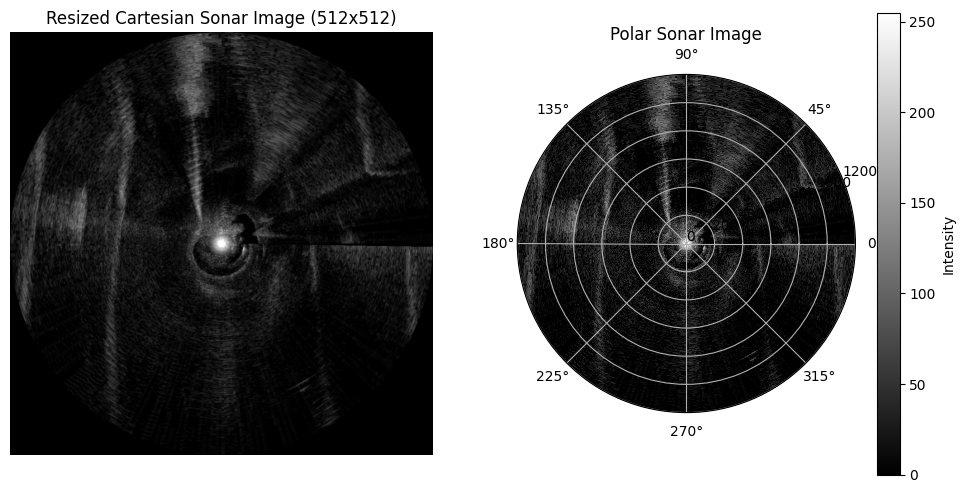

Resized Cartesian image saved at: cartesian_sonar1.png


In [28]:
# Example Usage
csv_path = "./sonar_csv/sonar_data_frame_52.csv"  # Update with actual CSV file path
save_path = "cartesian_sonar1.png"
sonar_csv_to_cartesian(csv_path, save_path)

In [41]:
import re

folder_path = './sonar_csv/with_coord/'

# Get list of all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if not f.startswith("._")]  # Remove macOS hidden files
# csv_files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))  # Sort numerically
csv_files.sort(key=lambda x: int(re.match(r'\d+', x).group()))


# Sort files based on the number in the filename
# csv_files.replace(".csv", "")

if not csv_files:
    print("No CSV files found in the folder.")
    exit()

In [42]:
csv_files

['001_72_244_41_235_67_154_99_163.csv',
 '002_104_269_83_269_84_194_107_194.csv',
 '003_136_161_112_152_119_106_148_117.csv',
 '004_98_240_78_240_59_176_99_170.csv',
 '005_169_161_145_169_131_121_159_111.csv',
 '006_71_224_26_216_53_105_89_124.csv',
 '007_163_282_114_289_111_216_158_217.csv',
 '008_174_267_139_269_136_220_169_218.csv',
 '009_201_274_168_278_164_212_197_211.csv',
 '010_136_316_97_329_75_227_116_221.csv',
 '011_138_254_97_246_117_168_153_178.csv']

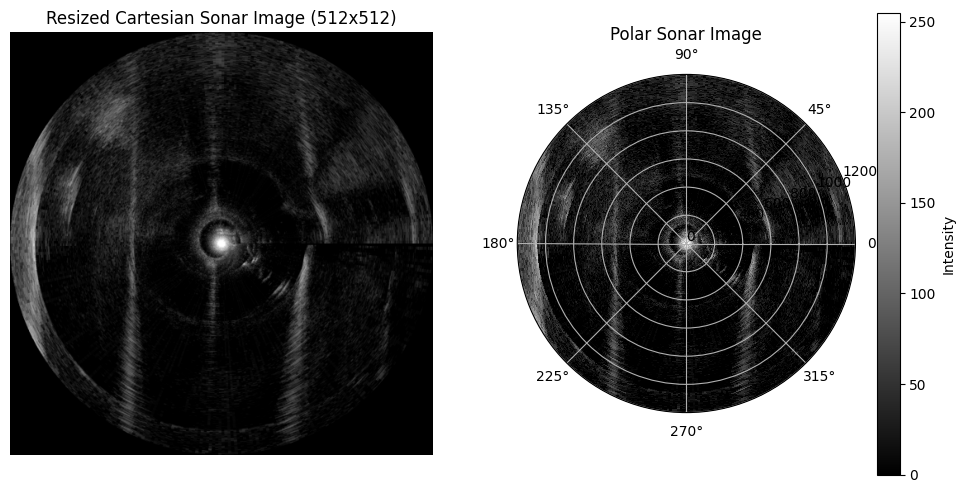

Resized Cartesian image saved at: ./sonar_png/with_coord\001_72_244_41_235_67_154_99_163.png


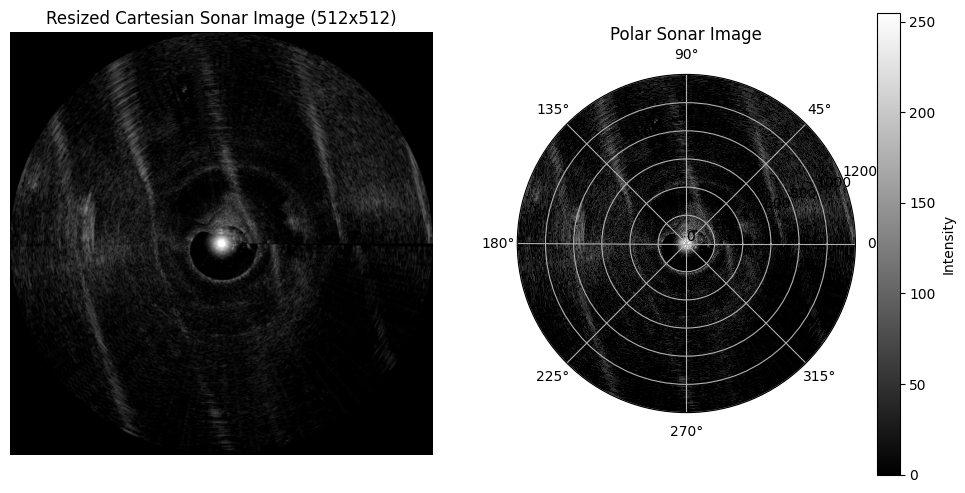

Resized Cartesian image saved at: ./sonar_png/with_coord\002_104_269_83_269_84_194_107_194.png


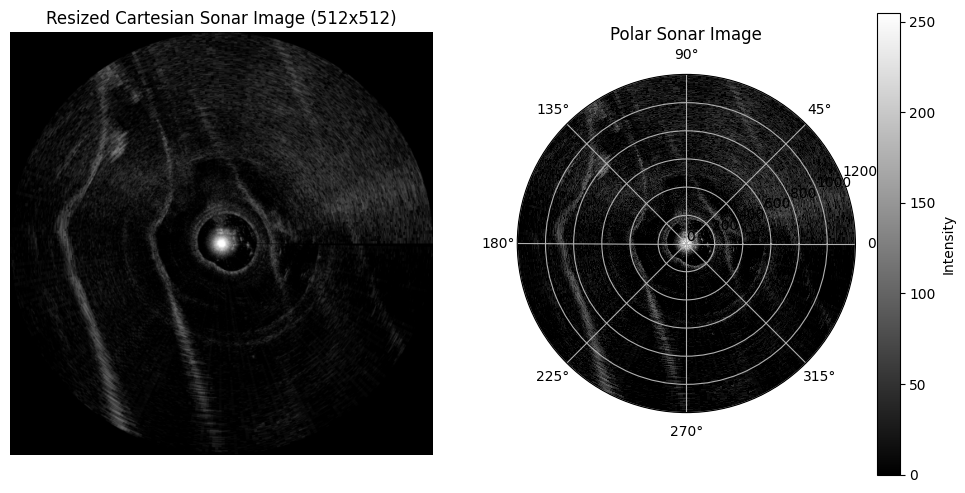

Resized Cartesian image saved at: ./sonar_png/with_coord\003_136_161_112_152_119_106_148_117.png


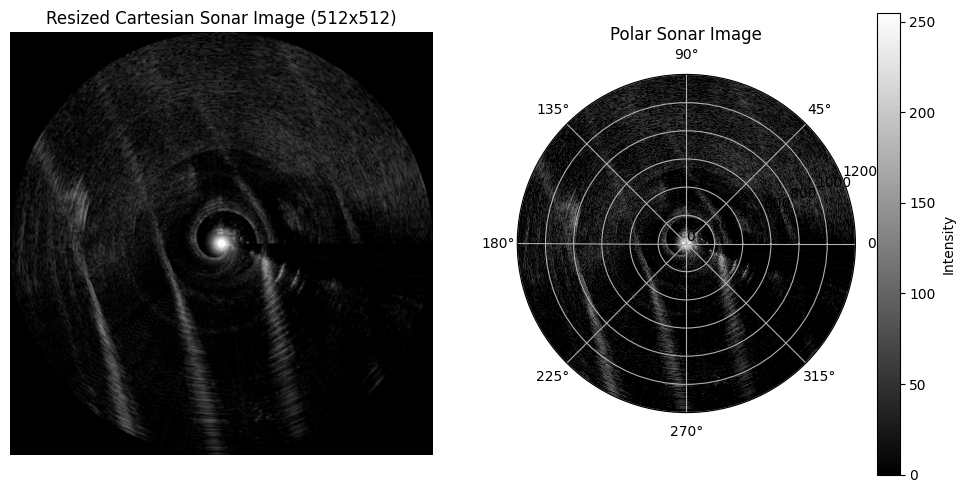

Resized Cartesian image saved at: ./sonar_png/with_coord\004_98_240_78_240_59_176_99_170.png


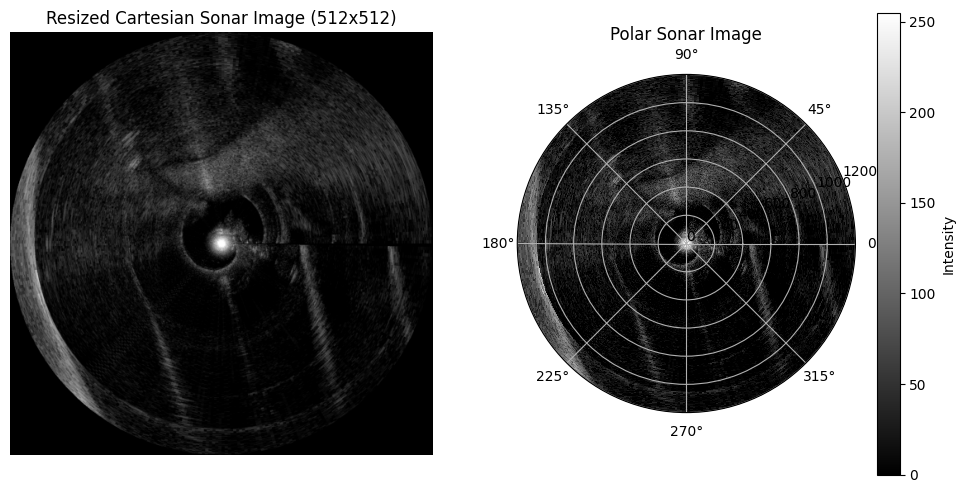

Resized Cartesian image saved at: ./sonar_png/with_coord\005_169_161_145_169_131_121_159_111.png


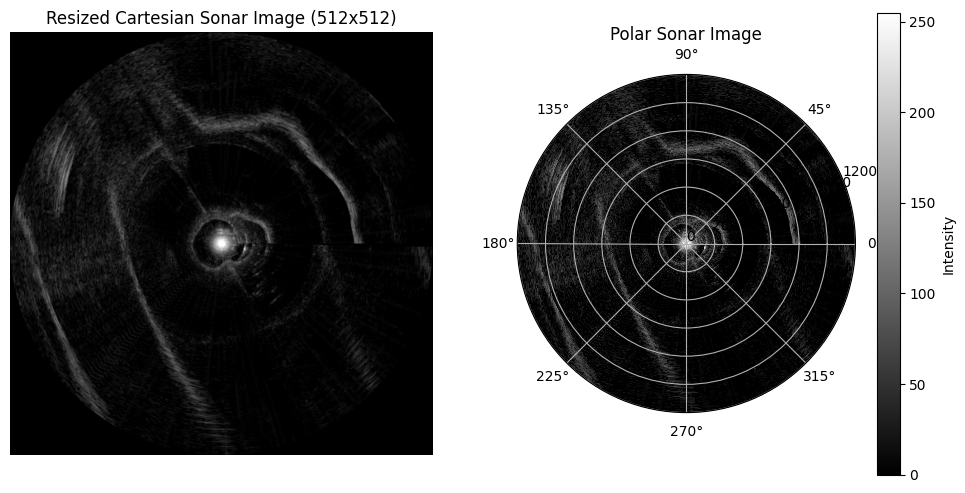

Resized Cartesian image saved at: ./sonar_png/with_coord\006_71_224_26_216_53_105_89_124.png


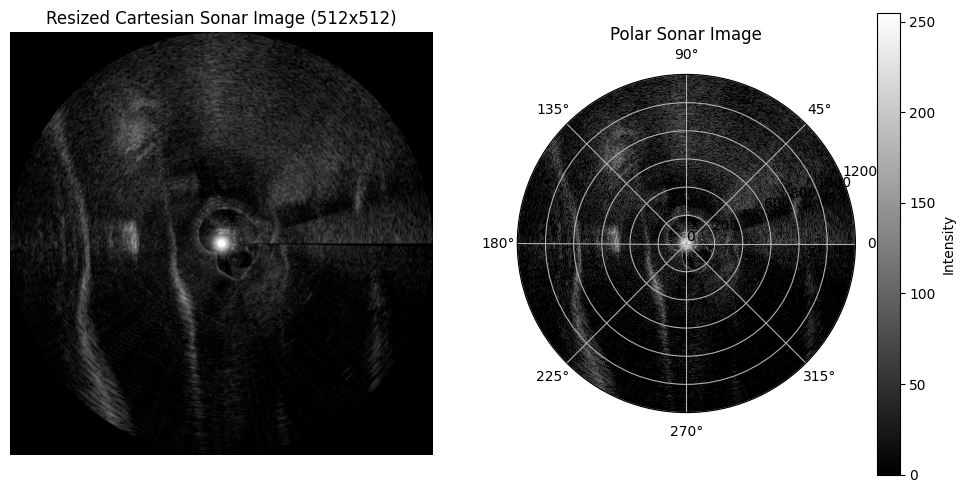

Resized Cartesian image saved at: ./sonar_png/with_coord\007_163_282_114_289_111_216_158_217.png


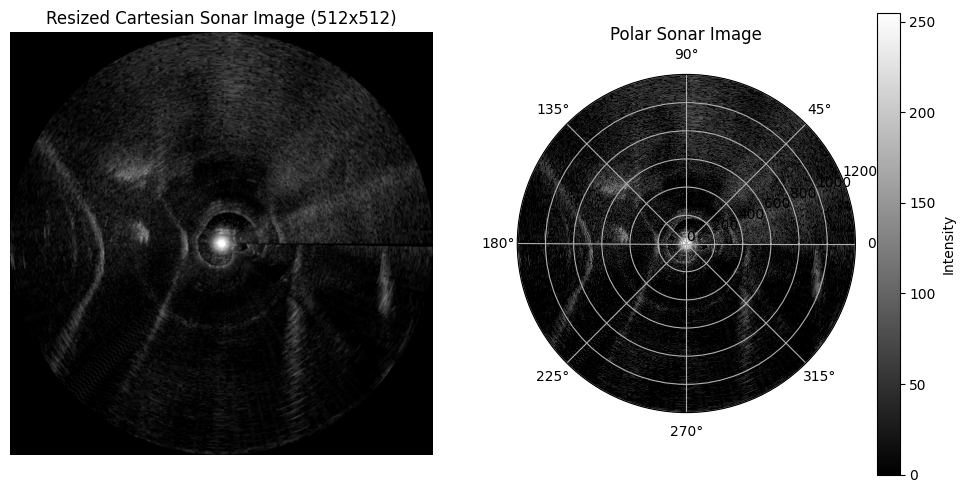

Resized Cartesian image saved at: ./sonar_png/with_coord\008_174_267_139_269_136_220_169_218.png


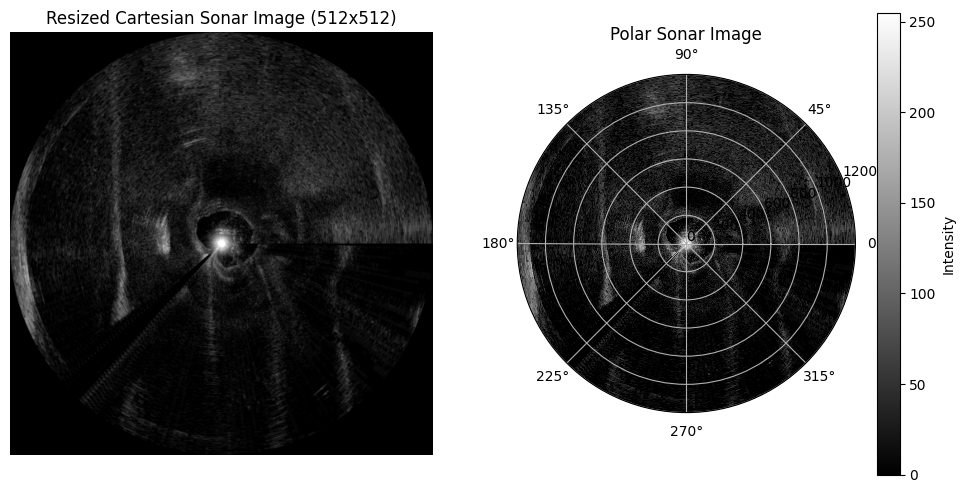

Resized Cartesian image saved at: ./sonar_png/with_coord\009_201_274_168_278_164_212_197_211.png


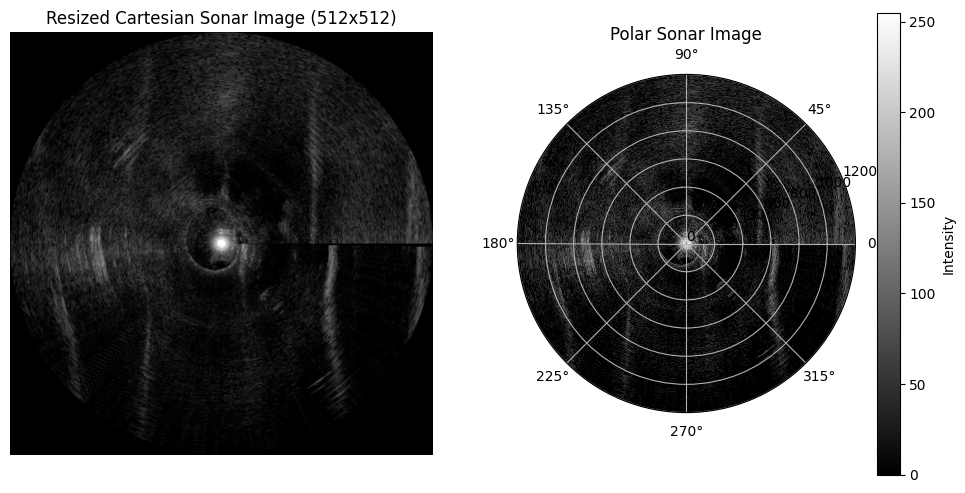

Resized Cartesian image saved at: ./sonar_png/with_coord\010_136_316_97_329_75_227_116_221.png


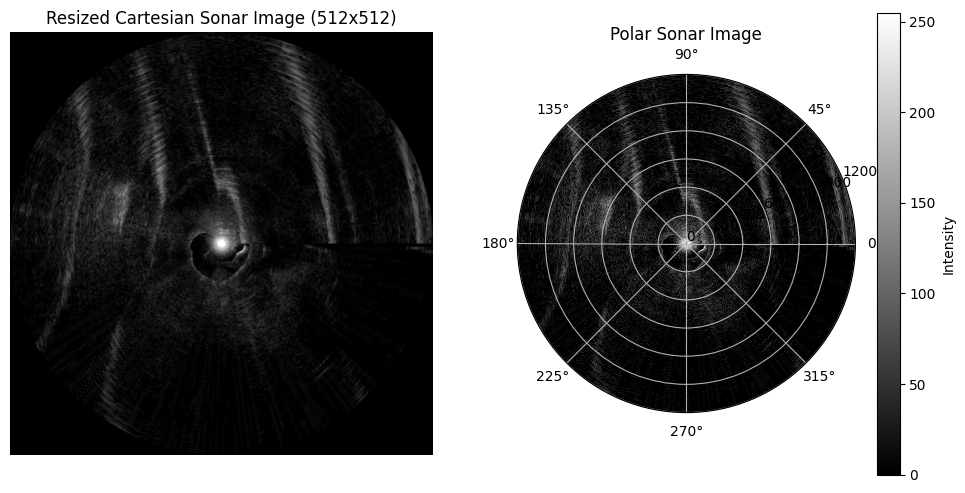

Resized Cartesian image saved at: ./sonar_png/with_coord\011_138_254_97_246_117_168_153_178.png


In [45]:
save_path = './sonar_png/with_coord'

for i, file_name in enumerate(csv_files):
    file_path = os.path.join(folder_path, file_name)
    image_path = os.path.join(save_path, file_name.replace(".csv", ".png"))  # Using f-string for readability
    sonar_csv_to_cartesian(file_path, image_path)

In [47]:
label_folder = './sonar_png/with_coord'
def convert_bbox_to_yolo(x1, y1, x2, y2, x3, y3, x4, y4, img_width, img_height):
    """Convert bounding box from (x1, y1, x2, y2, x3, y3, x4, y4) to YOLO format."""
    center_x = (x1 + x2 + x3 + x4) / 4.0
    center_y = (y1 + y2 + y3 + y4) / 4.0
    width = max(x1, x2, x3, x4) - min(x1, x2, x3, x4)
    height = max(y1, y2, y3, y4) - min(y1, y2, y3, y4)

    return [0, center_x / img_width, center_y / img_height, width / img_width, height / img_height]

# Convert all sonar bounding boxes
for csv_file in csv_files:
    if csv_file.endswith(".csv"):
        parts = csv_file.replace(".csv", "").split("_")

        if len(parts) >= 9:
            x1, y1, x2, y2, x3, y3, x4, y4 = map(int, parts[1:9])
            
            yolo_bbox = convert_bbox_to_yolo(x1, y1, x2, y2, x3, y3, x4, y4, 512, 512)

            label_file = os.path.join(label_folder, csv_file.replace(".csv", ".txt"))
            with open(label_file, "w") as f:
                f.write(" ".join(map(str, yolo_bbox)) + "\n")